## Introduction

In this notebook, we demonstrate the usage of `mmsws.computation.time_frequency` routines for frequency-domain analysis using short-time Fourier and wavelet transforms. We compare the results with manual calculations of the phase space density using `numpy.fft` routines.

## Reference event and data

We will use the July 2017 turbulent magnetotail reconnection event analyzed by [Ergun, R. E., Ahmadi, N., Kromyda, L., et al. 2020, ApJ, 898, 154](10.3847/1538-4357/ab9ab6). Below is an excerpt of their Figure 1.

![Ergun+20 event overview](data.zarr/time_frequency_analysis/resources/ergun+20_overview.png)

The turbulent magnetic field in panel (e) between 07:20 and 07:40 has the following spectrum.

<img src="data.zarr/time_frequency_analysis/resources/ergun+20_spectrum.png" width="50%" align="center">

We shall reproduce these calculations in subsequent sections. But first, let us sync the fluxgate magnetometer data for this event.


In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.")

import mmspy

mms = mmspy.api.MMS()
mms.query.start_date = "2017-07-26T07:20"
mms.query.end_date = "2017-07-26T07:40"
mms.query.probe = "mms2"
mms.query.instrument = "fgm"
mms.query.data_rate = "brst"
mms.query.data_type = "bfield"
mms.sync.store = "./data.zarr/time_frequency_analysis"

mms.sync.sync(dry_run=False)

#  from mmsws.sync import SyncFgm
#  
#  SyncFgm(
#      start_date="2017-07-26T07:20",
#      end_date="2017-07-26T07:40",
#      probe="mms2",
#      data_rate="brst",
#      storage="./data.zarr/time_frequency_analysis",
#  ).sync(parallel=4, dry_run=False)
#  

24-Nov-04 12:58:00 [INFO]: mms2_fgm_brst_l2_20170726073713_v5.98.0.cdf is up-to-date.                  
24-Nov-04 12:58:00 [INFO]: mms2_fgm_brst_l2_20170726073613_v5.98.0.cdf is up-to-date.                  
24-Nov-04 12:58:00 [INFO]: mms2_fgm_brst_l2_20170726073213_v5.98.0.cdf is up-to-date.                      
24-Nov-04 12:58:00 [INFO]: mms2_fgm_brst_l2_20170726073113_v5.98.0.cdf is up-to-date.                      
24-Nov-04 12:58:00 [INFO]: mms2_fgm_brst_l2_20170726072613_v5.98.0.cdf is up-to-date.                      
24-Nov-04 12:58:00 [INFO]: mms2_fgm_brst_l2_20170726072113_v5.98.0.cdf is up-to-date.                      
[################] [6/6 | 123.56it/s]: Synchronizing fgm bfield (2017-07-26 07:20:00 - 2017-07-26 07:40:00).


## Manual calculation of the power spectral density

We load relevant data


In [2]:
import xarray as xr
import numpy as np

ds = xr.open_mfdataset(
    "./data.zarr/time_frequency_analysis/mms2/fgm_bfield/brst/l2/*",
    engine="zarr",
).pint.quantify()
Bx = ds.B_gse.rank_1.component("x")
By = ds.B_gse.rank_1.component("y")
Bz = ds.B_gse.rank_1.component("z")

`mmsws.computation.time_frequency` provides a few functions for time-frequency analysis: `fft` calculates the spectrum for the entire signal; `stft` calculates the spectrum for a sliding window from a given signal; and `cwt` calculates the continuous wavelet transform for a given signal. There are also corresponding `xr_*` wrappers for xarray inputs.

`fft` only utilizes `numpy.fft` functions, so it is the most straightforward one. Below, we manually lay out the steps for calculating the one-sided FFT in that function.


In [3]:
from scipy.signal import get_window
from mmspy.utils import sampling_information

# Unpack sampling information
sampling = sampling_information(ds.time)
Ns = sampling["number_of_samples"]  # Number of samples
Ts = sampling["period"]             # Sampling period
fs = sampling["frequency"]             # Sampling period

# Calculate index slices for even and odd signal lengths
if Ns % 2 == 0:
    positive_indices = slice(1, Ns // 2)
    negative_indices = slice(Ns // 2 + 1, Ns)
else:
    positive_indices = slice(1, (Ns + 1) // 2)
    negative_indices = slice((Ns + 1) // 2, Ns)

# Calculate the two-sided FFT, forward normalization is (1 / Ns)
signal = Bx.data.compute()
window = get_window("hann", Ns)
f_twosided = np.fft.fftfreq(Ns, Ts)
F_twosided = np.fft.fft(signal.magnitude * window, norm="forward") * signal.units

# Fold over the two-sided results into a one-sided PSD
f_onesided = f_twosided[positive_indices]
df = np.diff(f_onesided).mean().to("Hz")
PSD = (2 / df) * (
    np.abs(F_twosided[positive_indices])**2 +
    np.abs(F_twosided[negative_indices][::-1])**2
)

Let us resample the above results for PSD[$B_x$] and plot them


24-Nov-04 12:58:00 [INFO]: Using tvolib stylesheet


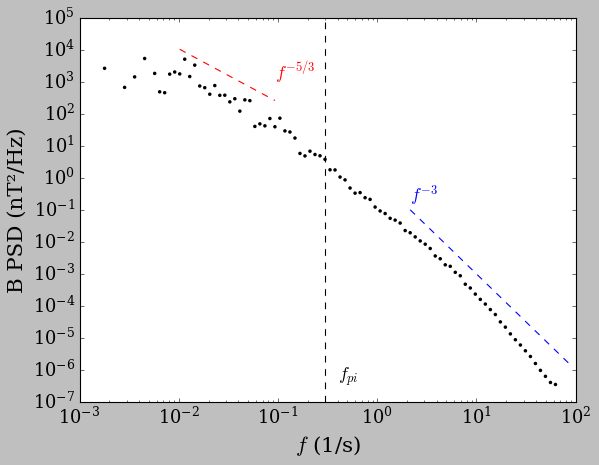

In [4]:
from tvolib import matplotlib_utils as mu

# Resample
f_bins = np.logspace(-3, 2, 100)
f_fft = f_bins[:-1]

H = np.histogram(f_onesided.magnitude, bins=f_bins)[0].astype(float)
Hf = np.histogram(f_onesided.magnitude, bins=f_bins, weights=PSD.magnitude)[0]
H[H == 0.0] = np.nan
S_fft = Hf / H

fig, ax = mu.plt.subplots(1, 1)

ax.scatter(f_fft, S_fft, fc="k", ec="none", s=10)

mask = (1e-2 <= f_fft) & (f_fft <= 1e-1)
ax.plot(x := f_fft[mask], y := 5e0 * f_fft[mask] ** (-5 / 3), "--r")
ax.text(x[-1], 5 * y[-1], "$f^{-5/3}$", c="r")

mask = f_fft >= 2e0
ax.plot(x := f_fft[mask], y := f_fft[mask] ** (-3), "--b")
ax.text(x[0], 2 * y[0], "$f^{-3}$", c="b")

ax.axvline(3e-1, ls="--", c="k")
ax.text(4e-1, 5e-7, "$f_{pi}$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e2)
ax.set_ylim(1e-7, 1e5)
ax.set_xlabel(f"$f$ ({f_onesided.units:~P})")
ax.set_ylabel(f"B PSD ({PSD.units:~P})")

mu.plt.show()

The above result is comparable to the reference figure in the previous section.

## Utility demonstration

Now, let us utilize the routines from `mmsws.computation.time_frequency`


In [5]:
from mmspy.computation import xr_fft, xr_stft, xr_cwt
from pint_xarray import unit_registry as u

# Full-signal PSD
kw = dict(normalization="density")
Sx_fft = xr_fft(Bx, **kw)
Sy_fft = xr_fft(By, **kw)
Sz_fft = xr_fft(Bz, **kw)
S_fft = (np.abs(Sx_fft)**2 + np.abs(Sy_fft)**2 + np.abs(Sz_fft)**2).sum("type")

# STFT PSD
kw = dict(window_length=u.Quantity(600, "s"), normalization="density")
Sx_stft = xr_stft(Bx, **kw)
Sy_stft = xr_stft(By, **kw)
Sz_stft = xr_stft(Bz, **kw)
S_stft = np.abs(Sx_stft)**2 + np.abs(Sy_stft)**2 + np.abs(Sz_stft)**2

# CWT PSD calculations
kw = dict(normalization="density", mask_cone_of_influence=True)
Sx_cwt = xr_cwt(Bx, **kw)
Sy_cwt = xr_cwt(By, **kw)
Sz_cwt = xr_cwt(Bz, **kw)
S_cwt = np.abs(Sx_cwt)**2 + np.abs(Sy_cwt)**2 + np.abs(Sz_cwt)**2

In time domain, the original signal and corresponding spectrograms are


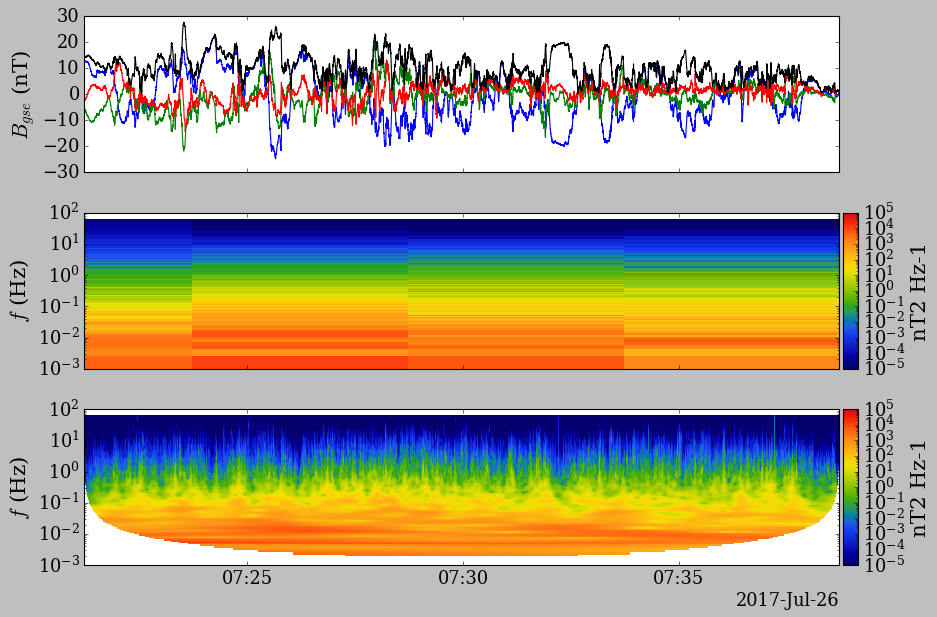

In [6]:
fig, axes = mu.plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pkw = dict(norm=mu.mplc.LogNorm(1e-5, 1e5), cmap="cet_rainbow4")

mu.add_colorbar(ax := axes[0]).remove()
ax.plot(ds.time, Bx, "-b")
ax.plot(ds.time, By, "-g")
ax.plot(ds.time, Bz, "-r")
ax.plot(ds.time, ds.B_gse.rank_1.magnitude.pint.dequantify(), "-k")
ax.set_ylabel("$B_{gse}$ (nT)")

cax = mu.add_colorbar(ax := axes[1])
im = ax.pcolormesh(
    *np.meshgrid(S_stft.time, S_stft.frequency, indexing="ij"),
    S_stft.transpose("time", "frequency").pint.dequantify(),
    **pkw,
)
cb = fig.colorbar(im, cax=cax)
cb.set_label(S_fft.pint.units)

cax = mu.add_colorbar(ax := axes[2])
im = ax.pcolormesh(
    *np.meshgrid(S_cwt.time, S_cwt.frequency, indexing="ij"),
    S_cwt.transpose("time", "frequency").pint.dequantify(),
    **pkw,
)
cb = fig.colorbar(im, cax=cax)
cb.set_label(S_fft.pint.units)

for (i, ax) in enumerate(axes):
    ax.set_xlim(ds.time[0], ds.time[-1])
    mu.format_datetime_labels(ax)
    if i > 0:
        ax.set_yscale("log")
        ax.set_ylim(1e-3, 1e2)
        ax.set_ylabel("$f$ (Hz)")

fig.tight_layout()
mu.plt.show()

In frequency domain, let us compare the three results


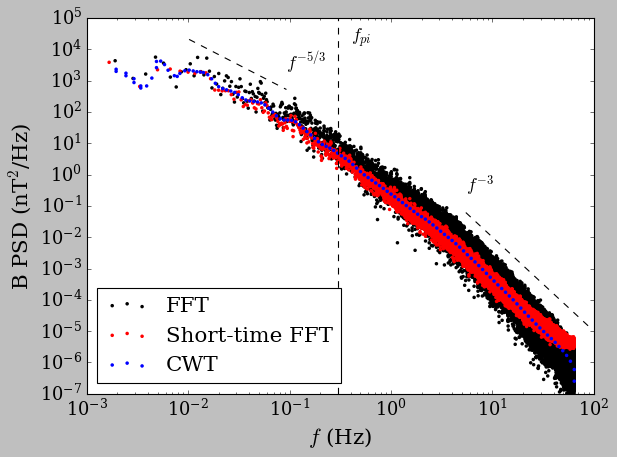

In [7]:
fig, ax = mu.plt.subplots(1, 1, figsize=(8, 6))

kw = dict(ec="none", s=10)
ax.scatter(S_fft.frequency, S_fft.pint.dequantify(), fc="k", label="FFT", **kw)
ax.scatter(S_stft.frequency, S_stft.mean("time").pint.dequantify(), fc="r", label="Short-time FFT", **kw)
ax.scatter(S_cwt.frequency, S_cwt.mean("time").pint.dequantify(), fc="b", label="CWT", **kw)

mask = (1e-2 <= f_fft) & (f_fft <= 1e-1)
ax.plot(x := f_fft[mask], y := 1e1 * f_fft[mask] ** (-5 / 3), "--k")
ax.text(x[-1], 5 * y[-1], "$f^{-5/3}$", c="k")

mask = f_fft >= 5e0
ax.plot(x := f_fft[mask], y := 1e1 * f_fft[mask] ** (-3), "--k")
ax.text(x[0], 5 * y[0], "$f^{-3}$", c="k")

ax.axvline(3e-1, ls="--", c="k")
ax.text(4e-1, 2e4, "$f_{pi}$")

ax.set_xlim(1e-3, 1e2)
ax.set_ylim(1e-7, 1e5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(loc="lower left")
ax.set_xlabel("$f$ (Hz)")
ax.set_ylabel("B PSD (nT$^2$/Hz)")

fig.tight_layout()
mu.plt.show()

Clearly, all three methods agree!

We can also reconstruct the time series from calculate spectra.


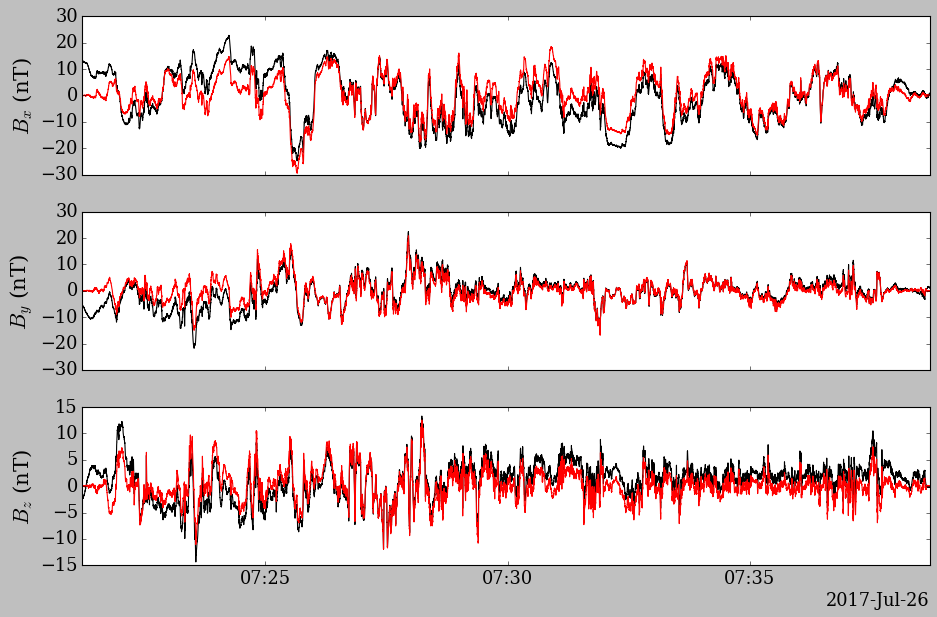

In [8]:
from mmspy.computation import xr_icwt

Bx_reconstructed = xr_icwt(Sx_cwt)
By_reconstructed = xr_icwt(Sy_cwt)
Bz_reconstructed = xr_icwt(Sz_cwt)

fig, axes = mu.plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(ds.time, Bx, "-k")
axes[0].plot(ds.time, Bx_reconstructed, "-r")
axes[0].set_ylabel("$B_x$ (nT)")

axes[1].plot(ds.time, By, "-k")
axes[1].plot(ds.time, By_reconstructed, "-r")
axes[1].set_ylabel("$B_y$ (nT)")

axes[2].plot(ds.time, Bz, "-k")
axes[2].plot(ds.time, Bz_reconstructed, "-r")
axes[2].set_ylabel("$B_z$ (nT)")

for (i, ax) in enumerate(axes):
    ax.set_xlim(ds.time[0], ds.time[-1])
    mu.format_datetime_labels(ax)

fig.tight_layout()
mu.plt.show()